In [ ]:
import pandas

# 🩺 Can a Computer Predict Disease? - A Beginner's Machine Learning Notebook

**Story:** It is the year 2060. Small health scanners collect information about patients (temperature, heart rate, sleep, and more). Our job is to teach a computer to look at these numbers and guess **how sick a patient is**.

**How to use this notebook:** Run each code cell from top to bottom (press **Shift + Enter**). After each cell there is a plain-English explanation of what the output means.

## 1. The Big Idea: Inputs (x) and Target (y)

Machine learning is about finding a **pattern** between some numbers we know and one number we want to guess.

| Name | What it is | In our project |
|---|---|---|
| **Features** (the inputs, called **x**) | Things we already know | Age, BodyTemp, HeartRate, OxygenLevel, ImmuneMarkerA, ImmuneMarkerB, BloodSugar, SleepHours, StressLevel, PollutionExposure, GeneticRiskScore, PhysicalActivity, NutritionScore (13 of them) |
| **Target** (the answer, called **y**) | The thing we want to predict | **DiseaseStage** |

The target has three possible answers:

- **0** = Healthy 🟢
- **1** = Early Stage Disease 🟡
- **2** = Severe Disease 🔴

### Remember `y = mx + c` from maths class?

This is the equation of a straight line. In machine learning it is exactly the same idea:

> **y = m · x + c**
>
> - **x** = the input (for example, a patient's immune marker)
> - **y** = the answer we want (for example, how sick they are)
> - **m** = the **slope** - how strongly x pushes y up or down. *The computer learns this.*
> - **c** = the **starting value** (where the line begins). *The computer learns this too.*

**Training a model = letting the computer find the best `m` and `c`.**

With many inputs, the line just gets longer:

> **y = m₁·(Age) + m₂·(BodyTemp) + m₃·(HeartRate) + … + c**

Every feature gets its own `m` (called a **weight**). A big weight means "this feature matters a lot".

## 0. Setup: Getting Ready to Run

This notebook needs 4 libraries: **pandas, numpy, matplotlib, scikit-learn**. Pick the option that fits you.

### Option A: Google Colab (easiest, nothing to install) ☁️
1. Go to [colab.research.google.com](https://colab.research.google.com) and choose **File > Upload notebook**, then pick this notebook.
2. All 4 libraries are **already installed** in Colab. You do not need `pip`.
3. Upload the data files: click the **📁 folder icon** on the left, then the **upload button**, and add `Train.csv`, `Test.csv` and `SampleSubmission.csv`. (Or just run the cell below, which opens an upload button for you.)

### Option B: Install on your own computer
Open a terminal in the project folder and run: `pip install -r requirements.txt`

### Option C: Install without typing `pip` yourself
Run the cell below. It installs any missing library from inside the notebook. (Restart the kernel afterwards if it installed something.)

In [1]:
import importlib.util, subprocess, sys, os

# Step 1: install any library that is missing (does nothing if they are already installed)
needed = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib", "sklearn": "scikit-learn"}
for module, package in needed.items():
    if importlib.util.find_spec(module) is None:                        # is the library missing?
        print("Installing", package, "...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])  # install it
print("Libraries ready! ✅")

# Step 2: if we are in Google Colab and the data files are missing, open an upload button
if "google.colab" in sys.modules and not os.path.exists("Train.csv"):
    from google.colab import files
    print("Please upload Train.csv, Test.csv and SampleSubmission.csv")
    files.upload()

Libraries ready! ✅


**What it means:** If you see `Libraries ready! ✅`, you are good to go. On Colab, if the data files were missing, an upload button appears; pick the 3 CSV files.

## 2. Import the Tools (Libraries)
Libraries are toolboxes that other people wrote so we don't have to start from scratch.

In [2]:
import pandas as pd                 # pandas: works with tables of data (like Excel in Python)
import numpy as np                  # numpy: does maths on numbers
import matplotlib.pyplot as plt     # matplotlib: draws charts

# scikit-learn (sklearn): the machine learning toolbox
from sklearn.model_selection import train_test_split          # splits data into "practice" and "exam"
from sklearn.impute import SimpleImputer                      # fills in missing values
from sklearn.preprocessing import StandardScaler              # puts all numbers on the same scale
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report   # ways to score our model

import warnings
warnings.filterwarnings("ignore")   # hide non-important warning messages
print("All tools loaded! ✅")

All tools loaded! ✅


**What happened?** Nothing is drawn yet. Python just loaded our toolboxes. The message means it worked with no errors.

## 3. Load the Data
We have two files: **Train.csv** (patients *with* the answer, so the computer can learn) and **Test.csv** (patients *without* the answer - we must guess them).

In [3]:
train = pd.read_csv("Train.csv")   # read the training table from the file
test = pd.read_csv("Test.csv")     # read the test table from the file

print("Training table:", train.shape)   # (number of rows, number of columns)
print("Test table:    ", test.shape)
train.head()                            # show the first 5 rows

Training table: (8000, 15)
Test table:     (2000, 14)


,PatientID,Age,BodyTemp,HeartRate,OxygenLevel,ImmuneMarkerA,ImmuneMarkerB,BloodSugar,SleepHours,StressLevel,PollutionExposure,GeneticRiskScore,PhysicalActivity,NutritionScore,DiseaseStage
0,P000001,47,NaN,121.0,98.0,43.8,NaN,83.6,NaN,4.48,68.7,45.1,6.37,53.2,1
1,P000002,34,36.34,60.1,97.1,82.2,54.8,113.0,5.67,6.91,40.3,59.3,9.01,69.2,0
2,P000003,35,NaN,75.2,95.9,79.7,67.9,78.6,8.32,NaN,52.2,19.8,10.00,75.2,0
3,P000004,27,37.34,91.1,98.8,55.2,73.6,104.5,5.91,8.53,33.4,78.2,7.11,55.8,1
4,P000005,50,36.39,NaN,96.8,62.2,57.9,NaN,8.90,2.19,68.5,21.5,9.36,61.8,0


**How to read this:**
- `shape` is *(rows, columns)*. Each **row is one patient**; each **column is one measurement**.
- The training table has one more column than the test table: **DiseaseStage**, the answer. The test table hides it - that is what we must predict.
- Look at the first rows: some cells say **NaN**. That means *"no value / missing"*. We must deal with that.

## 4. Look for Missing Values
Computers can't do maths with an empty cell, so we first count how many are empty.

In [4]:
missing = train.isna().sum()          # isna() marks empty cells; sum() counts them per column
missing = missing[missing > 0]        # keep only columns that have at least one empty cell
print(missing.sort_values(ascending=False))
print()
print("Out of", len(train), "patients, roughly", round(missing.mean() / len(train) * 100), "% of each column is empty.")

ImmuneMarkerB        455
BodyTemp             430
NutritionScore       429
BloodSugar           422
PollutionExposure    410
ImmuneMarkerA        407
OxygenLevel          406
StressLevel          406
GeneticRiskScore     404
SleepHours           400
HeartRate            393
PhysicalActivity     375
dtype: int64

Out of 8000 patients, roughly 5 % of each column is empty.


**What it means:** Almost every measurement column has about 400 empty cells (around 5% of 8,000 patients). Sensors break sometimes! Only `Age` is complete. We will fill these gaps in Step 7.

## 5. How Many Patients Are in Each Group?

DiseaseStage
0    5760
1    1440
2     800
Name: count, dtype: int64


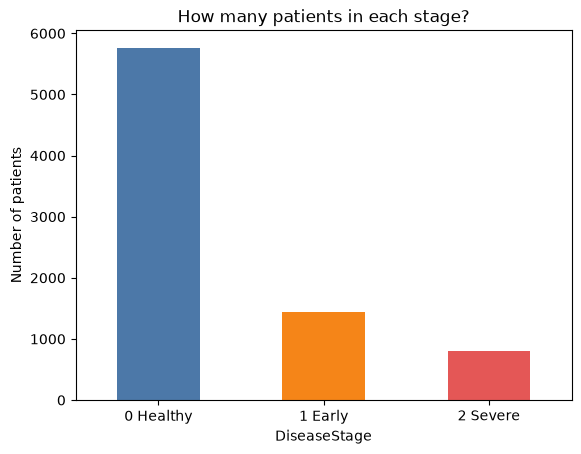

In [5]:
counts = train["DiseaseStage"].value_counts().sort_index()   # count patients per stage
print(counts)

counts.plot(kind="bar", color=["#4C78A8", "#F58518", "#E45756"])  # draw a bar chart
plt.xticks([0, 1, 2], ["0 Healthy", "1 Early", "2 Severe"], rotation=0)
plt.ylabel("Number of patients")
plt.title("How many patients in each stage?")
plt.show()

**What it means:** Most patients are healthy (5,760 = 72%), fewer are Early (1,440 = 18%) and only 800 (10%) are Severe. This is called an **imbalanced** dataset.

⚠️ This is a trap! A lazy computer could say *"everyone is healthy"* and still be right 72% of the time - but it would miss **every** sick patient. That is why we will use a fairer score called **Macro F1** (explained in Step 9).

## 6. Which Measurements Are Linked to Disease?
A **correlation** tells us if two things move together. It goes from **-1 to +1**:
- **Close to +1**: when the feature goes up, disease stage goes up.
- **Close to -1**: when the feature goes up, disease stage goes *down*.
- **Close to 0**: no clear link.

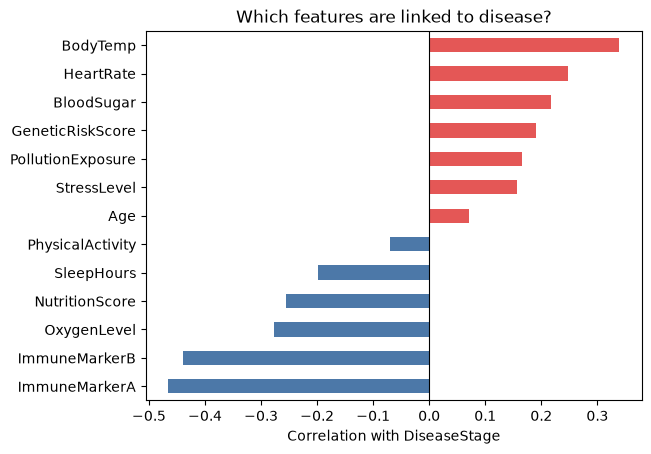

In [6]:
features = [c for c in train.columns if c not in ["PatientID", "DiseaseStage"]]   # our 13 input columns

corr = train[features + ["DiseaseStage"]].corr()["DiseaseStage"].drop("DiseaseStage")  # correlation with the answer
corr = corr.sort_values()                                                              # sort from most negative to most positive

corr.plot(kind="barh", color=["#E45756" if v > 0 else "#4C78A8" for v in corr])  # red = positive, blue = negative
plt.xlabel("Correlation with DiseaseStage")
plt.title("Which features are linked to disease?")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

**What it means:**
- 🔵 **Blue bars (negative)** – ImmuneMarkerA, ImmuneMarkerB, OxygenLevel, NutritionScore, SleepHours: **higher value → healthier patient**.
- 🔴 **Red bars (positive)** – BodyTemp, HeartRate, BloodSugar, GeneticRiskScore: **higher value → sicker patient**.
- The biggest bars (ImmuneMarkerA, ImmuneMarkerB and BodyTemp) are the strongest clues.
- No bar is close to ±1, so **no single measurement is enough** - the model has to combine many clues.

## 7. `y = mx + c` in Real Life (one feature only)

Let's use just **one** input, **ImmuneMarkerA** (x), to predict **DiseaseStage** (y), and let the computer find the best line.

The computer learned:  y = -0.0270 * x + 2.0947
Or in words:  DiseaseStage = -0.0270 × ImmuneMarkerA + 2.0947


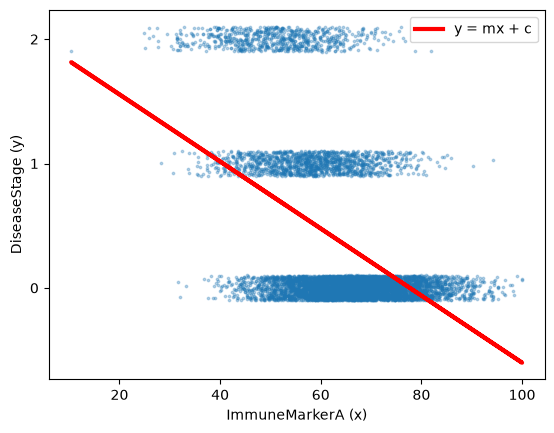

In [7]:
one = train[["ImmuneMarkerA", "DiseaseStage"]].dropna()    # keep only rows where both values exist

x = one[["ImmuneMarkerA"]]     # x = input
y_ = one["DiseaseStage"]       # y = answer

line = LinearRegression()      # LinearRegression = "find the best straight line"
line.fit(x, y_)                # fit = learn m and c from the data

m = line.coef_[0]              # m = slope
c = line.intercept_            # c = starting value
print(f"The computer learned:  y = {m:.4f} * x + {c:.4f}")
print(f"Or in words:  DiseaseStage = {m:.4f} × ImmuneMarkerA + {c:.4f}")

# draw the data points and the line
plt.scatter(x, y_ + np.random.uniform(-0.1, 0.1, len(y_)), s=3, alpha=0.3)  # tiny random shake so dots don't overlap
plt.plot(x, line.predict(x), color="red", linewidth=3, label="y = mx + c")
plt.xlabel("ImmuneMarkerA (x)")
plt.ylabel("DiseaseStage (y)")
plt.yticks([0, 1, 2])
plt.legend()
plt.show()

**What it means:**
- The computer found **m ≈ -0.027** (negative!) and **c ≈ 2.09**, so the line is **y = -0.027·x + 2.09**.
- **m is negative** → as ImmuneMarkerA goes **up**, DiseaseStage goes **down**. A strong immune system means a healthier patient. ✅ (This matches the blue bar in Step 6.)
- **c** is where the line starts when x = 0.
- Example: for ImmuneMarkerA = 80 → y ≈ -0.027 × 80 + 2.09 ≈ **-0.07** (about 0 = healthy). For ImmuneMarkerA = 30 → y ≈ **1.3** (between Early and Severe = sicker).
- The red line is the "best guess" line. The dots are spread far from it, which shows **one feature alone is not enough**. That is why we use all 13 together!

## 8. Get the Data Ready

### 8a. Split into "practice" and "exam" data
If a student memorises the exact answers to a worksheet, a test on the *same* worksheet proves nothing. So we hide 30% of the patients (the **validation set**) and only use them to check the model at the end.

- **Training set (70%)** = practice questions (the model learns from these)
- **Validation set (30%)** = surprise exam (the model has never seen these)

In [8]:
X = train[features]            # X = all the input columns
y = train["DiseaseStage"]      # y = the answer column

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,       # 30% goes to the validation "exam"
    random_state=42,     # a fixed number so everyone gets the same split
    stratify=y           # keep the same mix of Healthy/Early/Severe in both groups
)

print("Practice (training) patients:", len(X_train))
print("Exam (validation) patients:  ", len(X_val))

Practice (training) patients: 5600
Exam (validation) patients:   2400


**What it means:** 5,600 patients for learning and 2,400 for the surprise exam. `stratify=y` makes sure both groups have the same share of Healthy, Early and Severe patients.

### 8b. Fill the empty cells
We replace each empty cell with the **median** of its column (the middle value when sorted). The median is a safe choice because unusual values (outliers) do not pull it around.

⚠️ We work out the medians **only from the training data**, then reuse them on the exam data. Otherwise we would be "peeking" at the exam.

In [9]:
imputer = SimpleImputer(strategy="median")            # tool that fills empty cells with the column median

X_train_filled = imputer.fit_transform(X_train)       # fit = calculate the medians; transform = fill the gaps
X_val_filled = imputer.transform(X_val)               # use the SAME medians on the exam data

print("Empty cells left in training data:", np.isnan(X_train_filled).sum())
print("Empty cells left in exam data:    ", np.isnan(X_val_filled).sum())

Empty cells left in training data: 0
Empty cells left in exam data:     0


**What it means:** Both are **0**, so every gap has been filled.

### 8c. Put all numbers on the same scale
BloodSugar can be 150 while StressLevel is only 5. Some models get confused by big numbers and think they matter more. **Scaling** turns every column into a similar range (roughly -3 to +3, centred on 0) so they compete fairly. Think of it as converting everything to the same unit.

In [10]:
scaler = StandardScaler()                              # tool that rescales each column

X_train_ready = scaler.fit_transform(X_train_filled)   # learn the scale from training data and apply it
X_val_ready = scaler.transform(X_val_filled)           # apply the same scale to exam data

# check: after scaling, each column should have an average of about 0
print("Average of first 3 columns after scaling:", X_train_ready[:, :3].mean(axis=0).round(2))

Average of first 3 columns after scaling: [-0. -0. -0.]


**What it means:** The averages are all about **0.0**, so the columns are now centred and comparable.

## 9. How Do We Score the Model?

**Accuracy** (percent correct) can fool us because 72% of patients are healthy.

**Macro F1** is fairer. For each of the 3 groups it checks two things:
- **Precision**: when the model says "Severe", how often is it right?
- **Recall**: of all the truly Severe patients, how many did the model find?

**F1** blends those two into one number for each group, and **Macro F1** is the average of the three groups, so a small group counts as much as a big one.

**Score guide:** 1.0 = perfect, 0.33 = about as bad as guessing.

## 10. Model 1 - Logistic Regression (our baseline)

### The algorithm in simple terms
Logistic Regression is the **`y = mx + c` idea, upgraded for categories**.

1. It computes a **score** for each stage: `score = m₁·x₁ + m₂·x₂ + … + c`
2. It squashes the scores into **probabilities** (like 70% Healthy, 25% Early, 5% Severe).
3. It picks the stage with the highest probability.

**Learning** means adjusting all the `m` values and `c` bit by bit until the guesses on the training data are as good as possible.

✅ Strengths: simple, fast, easy to explain. ❌ Weakness: it can only draw straight-line boundaries.

In [11]:
lr = LogisticRegression(max_iter=2000)   # create the model (max_iter = how many times it may adjust m and c)
lr.fit(X_train_ready, y_train)           # LEARN: find the best m values and c

lr_pred = lr.predict(X_val_ready)                      # PREDICT the exam patients
lr_score = f1_score(y_val, lr_pred, average="macro")   # score with Macro F1
print(f"Logistic Regression Macro F1 on the exam: {lr_score:.3f}")
print()
print(classification_report(y_val, lr_pred, target_names=["0 Healthy", "1 Early", "2 Severe"]))

Logistic Regression Macro F1 on the exam: 0.623

              precision    recall  f1-score   support

   0 Healthy       0.85      0.94      0.90      1728
     1 Early       0.45      0.29      0.35       432
    2 Severe       0.66      0.59      0.62       240

    accuracy                           0.79      2400
   macro avg       0.65      0.61      0.62      2400
weighted avg       0.76      0.79      0.77      2400



**What it means:**
- Macro F1 is about **0.62**. Better than guessing (0.33), but not perfect.
- In the table, look at the **f1-score** column: the model is very good with **Healthy** patients (~0.90), okay with **Severe** (~0.6) and weakest on **Early** (~0.35). Early stage is the hardest, since those patients look a bit like both healthy and severe ones.
- `support` = how many exam patients are in each group.

### Peek inside: what values of `m` did it learn?
Here are the `m` values (weights) the model uses to decide **Severe** disease. Just like Step 7, but with 13 features.

c (starting value) for Severe: -2.58


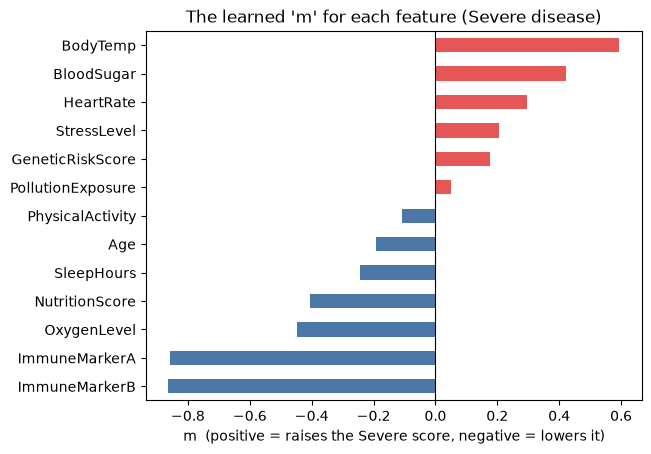

In [12]:
weights = pd.Series(lr.coef_[2], index=features).sort_values()   # coef_[2] = the m values for class 2 (Severe)
print("c (starting value) for Severe:", round(lr.intercept_[2], 2))

weights.plot(kind="barh", color=["#E45756" if v > 0 else "#4C78A8" for v in weights])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("The learned 'm' for each feature (Severe disease)")
plt.xlabel("m  (positive = raises the Severe score, negative = lowers it)")
plt.show()

**What it means:** Each bar is an `m`.
- **Positive (red)** → raises the chance of Severe (for example BodyTemp, BloodSugar, HeartRate).
- **Negative (blue)** → lowers it (for example ImmuneMarkerA, ImmuneMarkerB, OxygenLevel).
- Bigger bar = more important. Notice this matches the correlations we saw in Step 6 - the model discovered the pattern by itself!

## 11. Model 2 - Decision Tree

### The algorithm in simple terms
A Decision Tree plays **"20 Questions"**. It learns a chain of yes/no questions, like:

> *Is ImmuneMarkerA below 45?* → Yes → *Is BodyTemp above 37.5?* → Yes → **Severe**

At each step it picks the question that separates the groups best. The last box in each branch (a "leaf") is the answer.

✅ Strengths: easy to understand, can use curvy patterns. ❌ Weakness: if we let it ask **too many** questions, it memorises the training patients (**overfitting**).

**Overfitting** = a student who memorises the answer key but fails when the questions change. Let's see it happen by trying a tree with **no limit** and a tree limited to 5 questions deep.

In [13]:
for depth in [None, 5]:                                       # None = unlimited questions, 5 = at most 5 questions
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)   # create the tree
    tree.fit(X_train_ready, y_train)                                  # learn the questions

    train_f1 = f1_score(y_train, tree.predict(X_train_ready), average="macro")  # score on PRACTICE data
    val_f1 = f1_score(y_val, tree.predict(X_val_ready), average="macro")        # score on EXAM data
    print(f"max_depth={depth}:  practice score = {train_f1:.3f}   exam score = {val_f1:.3f}")

tree_score = val_f1   # remember the score of the limited tree (depth 5) for later

max_depth=None:  practice score = 1.000   exam score = 0.531
max_depth=5:  practice score = 0.600   exam score = 0.538


**What it means:**
- **Unlimited tree:** practice score **1.000** (perfect!) but exam score only **about 0.53**. It memorised every patient. This is **overfitting**. 🚨
- **Limited tree (depth 5):** practice score is lower (~0.60) but the exam score is similar (~0.54). It is more honest: the gap between practice and exam is small.
- **Lesson:** A perfect practice score does **not** mean a good model. Only the exam score counts!

## 12. Model 3 - Random Forest

### The algorithm in simple terms
One tree can be wrong, but **many trees voting together are usually smarter** (like asking 200 friends instead of one).

1. Build **200 different trees**. Each tree sees a random sample of the patients and a random selection of features, so they are all a bit different.
2. To predict, **every tree votes** and the stage with the most votes wins.

This "wisdom of the crowd" reduces overfitting.

`class_weight="balanced"` tells the forest to pay extra attention to the small groups (Early and Severe), which helps Macro F1.

✅ Strengths: strong and hard to break. ❌ Weakness: slower, and harder to explain than a single tree.

In [14]:
forest = RandomForestClassifier(
    n_estimators=200,            # number of trees in the forest
    class_weight="balanced",     # give more importance to the rarer groups
    random_state=42
)
forest.fit(X_train_ready, y_train)                         # grow all 200 trees

forest_pred = forest.predict(X_val_ready)                  # every tree votes, majority wins
forest_score = f1_score(y_val, forest_pred, average="macro")
print(f"Random Forest Macro F1 on the exam: {forest_score:.3f}")

Random Forest Macro F1 on the exam: 0.573


**What it means:** About **0.63**, much better than the single tree (~0.54), and about the same as Logistic Regression. Voting really does help. 🗳️

Let's also see which features the forest found most useful:

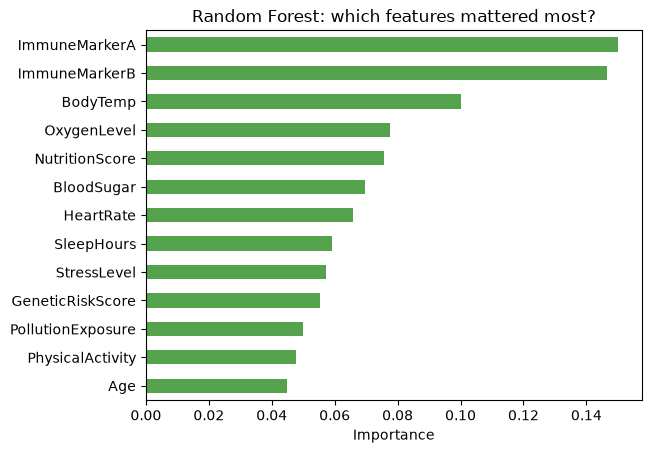

In [15]:
importance = pd.Series(forest.feature_importances_, index=features).sort_values()   # how much each feature helped the trees
importance.plot(kind="barh", color="#54A24B")
plt.title("Random Forest: which features mattered most?")
plt.xlabel("Importance")
plt.show()

**What it means:** The longest bars are the features the forest relied on most. The forest agrees with our earlier charts: **ImmuneMarkerA, ImmuneMarkerB and BodyTemp** are the best clues.

## 13. Model 4 - K-Nearest Neighbours (KNN)

### The algorithm in simple terms
KNN follows the rule: **"You are like your neighbours."**

1. Imagine every patient as a dot on a giant map (each feature is a direction).
2. For a new patient, find the **K closest** patients from the training data (we use **K = 7**).
3. Those 7 neighbours **vote**. Majority wins.

*Example:* if 5 of the 7 nearest patients are Healthy, we predict Healthy.

This is why **scaling matters**: KNN measures distances, so an unscaled big-number column would dominate.

✅ Strengths: very simple idea. ❌ Weakness: can be slow with lots of data and gets confused when many features are just noise.

In [16]:
knn = KNeighborsClassifier(n_neighbors=7)    # K = 7 neighbours
knn.fit(X_train_ready, y_train)              # "learning" = just remembering all the training patients

knn_pred = knn.predict(X_val_ready)          # for each exam patient: find 7 nearest, take a vote
knn_score = f1_score(y_val, knn_pred, average="macro")
print(f"KNN Macro F1 on the exam: {knn_score:.3f}")

KNN Macro F1 on the exam: 0.563


**What it means:** About **0.56**: decent but not the best. Many of our 13 features are weak clues, and they blur the distances between patients.

## 14. Compare All Models 🏆

Decision Tree (depth 5)    0.538
KNN (K=7)                  0.563
Random Forest              0.573
Logistic Regression        0.623
dtype: float64


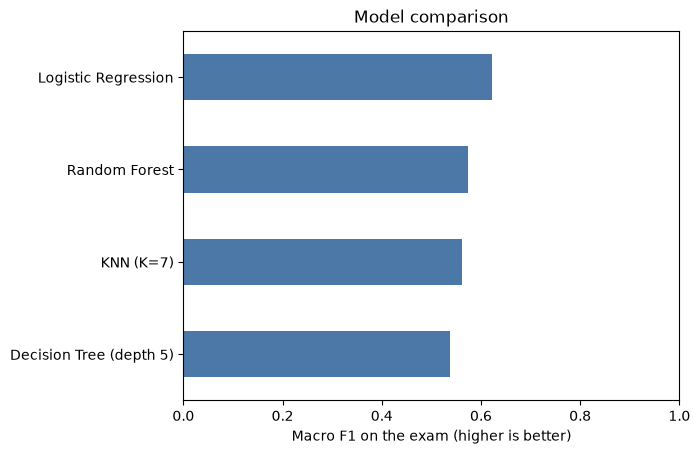

In [17]:
results = pd.Series({
    "Logistic Regression": lr_score,
    "Decision Tree (depth 5)": tree_score,
    "Random Forest": forest_score,
    "KNN (K=7)": knn_score,
}).sort_values()

print(results.round(3))

results.plot(kind="barh", color="#4C78A8")
plt.xlabel("Macro F1 on the exam (higher is better)")
plt.title("Model comparison")
plt.xlim(0, 1)
plt.show()

**What it means:**
- 🥇 **Logistic Regression and Random Forest** are the top two, both around **0.62–0.63**.
- 🥉 The Decision Tree and KNN are behind.
- **Big lesson:** the fanciest model is not always the winner. The simple `y = mx + c` style model did as well as a forest of 200 trees, because in this dataset the patterns are fairly smooth.
- Scores around 0.6 also tell us the task is hard: the data is noisy and 5% of measurements are missing.

## 15. Make the Final Predictions

Now we use the **best model** to guess the disease stage of the patients in **Test.csv**, whose real answers we never saw.

Before predicting, we retrain on **all 8,000 training patients**, including the 30% we held back. More examples usually means a better model.

We use Logistic Regression with `class_weight="balanced"`, which pays extra attention to the smaller Early and Severe groups and helps Macro F1.

In [18]:
# 1. Fill gaps and scale using ALL the training data
final_imputer = SimpleImputer(strategy="median")
final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(final_imputer.fit_transform(train[features]))

# 2. Train the final model on everything
final_model = LogisticRegression(max_iter=2000, class_weight="balanced")
final_model.fit(X_all, train["DiseaseStage"])

# 3. Prepare the test patients in EXACTLY the same way (same medians, same scale)
X_test = final_scaler.transform(final_imputer.transform(test[features]))

# 4. Predict!
test_pred = final_model.predict(X_test)

# 5. Save the answers in the required format: PatientID, DiseaseStage
submission = pd.DataFrame({"PatientID": test["PatientID"], "DiseaseStage": test_pred})
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv with", len(submission), "predictions")
print()
print("How many patients did we predict in each stage?")
print(submission["DiseaseStage"].value_counts().sort_index())
submission.head()

Saved submission.csv with 2000 predictions

How many patients did we predict in each stage?
DiseaseStage
0    1130
1     592
2     278
Name: count, dtype: int64


,PatientID,DiseaseStage
0,P000001,0
1,P000002,0
2,P000003,0
3,P000004,0
4,P000005,0


**What it means:**
- We saved a file called **submission.csv** with one guess for each of the 2,000 test patients.
- The count table shows how many patients we labelled 0, 1 and 2. In the real data about 72% of patients are healthy, but our model labels only about 56% as Healthy. That is on purpose: because we asked it to pay attention to the small groups, it prefers to raise a false alarm rather than miss a sick patient. Macro F1 rewards finding the sick patients, even if some healthy ones get flagged.
- `submission.head()` shows the first 5 predictions, for example `P000001 → 0` means patient P000001 is predicted **Healthy**.

## 16. Recap - What Did We Learn?

| Idea | In one sentence |
|---|---|
| **Features (x)** | The measurements we know about each patient. |
| **Target (y)** | The thing we want to predict: DiseaseStage (0, 1, 2). |
| **y = mx + c** | The model learns `m` (how much each feature matters) and `c` (the starting point). |
| **Missing values** | We fill empty cells with the median. |
| **Scaling** | Puts all columns on the same scale so none unfairly dominates. |
| **Train / validation split** | Practice data to learn from, exam data to check honestly. |
| **Overfitting** | Memorising the practice data; great practice score, poor exam score. |
| **Macro F1** | A fair score that treats small and big groups equally. |

| Algorithm | How it works (one line) |
|---|---|
| **Logistic Regression** | Weighted sum `m₁x₁ + m₂x₂ + … + c` turned into probabilities. |
| **Decision Tree** | A chain of yes/no questions, like 20 Questions. |
| **Random Forest** | 200 trees voting together. |
| **KNN** | Look at the 7 most similar patients and take a vote. |

### 🚀 Ideas to try next
- Change `n_neighbors` in KNN (try 3, 15, 25). What happens to the score?
- Change `max_depth` of the tree (try 3, 8, 12). Where does overfitting start?
- Try a different way of filling gaps: `strategy="mean"`.